# Car Price Prediction using Linear Regression

Research AI Task 6

The aim is to predict car prices using linear regression without using scikit-learn.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the dataset

In [2]:
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Basic inspection

In [3]:
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)

Shape: (205, 26)

Missing values: 0

Data types:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object


## 4. Select features

In [4]:
numeric_features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["price", "car_ID"]
]

categorical_features = [
    col for col in df.select_dtypes(include="object").columns
    if col != "CarName"
]

X_df = pd.get_dummies(
    df[numeric_features + categorical_features],
    drop_first=True,
    dtype=float
)

X = X_df.to_numpy()
y = df["price"].to_numpy()

print("Number of features:", X.shape[1])

Number of features: 43


## 5. Train-test split

In [5]:
rng = np.random.default_rng(42)
indices = rng.permutation(len(X))

split = int(0.8 * len(X))
train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 164
Testing samples: 41


## 6. Feature scaling

In [6]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0, ddof=1)

keep = std > 0

X_train = (X_train[:, keep] - mean[keep]) / std[keep]
X_test = (X_test[:, keep] - mean[keep]) / std[keep]

X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

## 7. Linear regression using gradient descent

In [7]:
theta = np.zeros(X_train.shape[1])

learning_rate = 0.01
iterations = 20000
cost_history = []

for i in range(iterations):
    error = X_train @ theta - y_train
    gradient = (X_train.T @ error) / len(X_train)
    theta -= learning_rate * gradient

    if i % 100 == 0:
        cost = np.mean((X_train @ theta - y_train) ** 2) / 2
        cost_history.append(cost)

## 8. Cost function during training

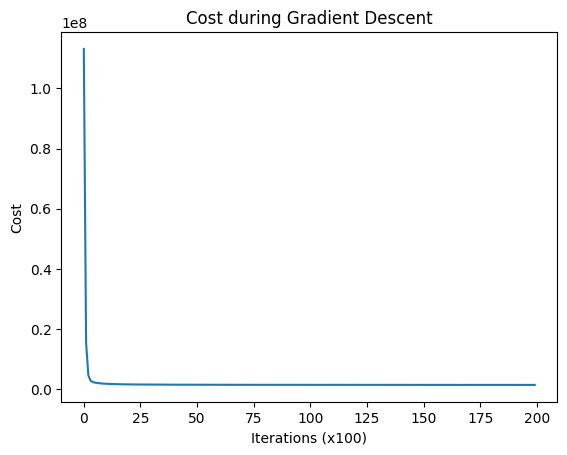

In [8]:
plt.plot(cost_history)
plt.xlabel("Iterations (x100)")
plt.ylabel("Cost")
plt.title("Cost during Gradient Descent")
plt.show()

## 9. Predictions

In [9]:
train_predictions = X_train @ theta
test_predictions = X_test @ theta

print("First 10 actual prices:")
print(y_test[:10])

print("\nFirst 10 predicted prices:")
print(test_predictions[:10])

First 10 actual prices:
[ 9298.  7957.  8238.  8948. 30760.  8495. 12440. 18620.  6855. 41315.]

First 10 predicted prices:
[ 8062.73221284  9461.0415943   7792.61126257  9445.66194493
 28091.04318379 11084.311317   12546.89202834 10670.44330433
  7270.6545396  28344.04521642]


## 10. Model evaluation

In [10]:
mse = np.mean((test_predictions - y_test) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum((y_test - test_predictions) ** 2) / np.sum(
    (y_test - y_test.mean()) ** 2
)

print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MSE : 12029795.510084728
RMSE: 3468.3995603281824
R2  : 0.8290916533992336


## 11. Actual vs predicted prices

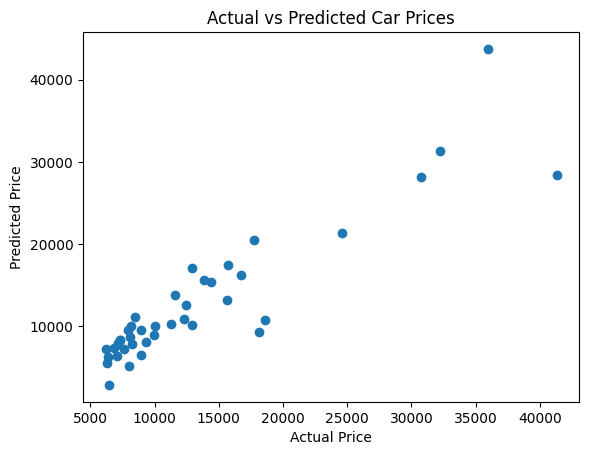

In [11]:
plt.scatter(y_test, test_predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

## 12. Result

The model was trained using 80% of the dataset and tested on the remaining 20%.

- Training samples: 164
- Testing samples: 41
- Test MSE: 12,029,795.51
- Test RMSE: 3,468.40
- Test R²: 0.829

The model gives a reasonable baseline for predicting car prices using linear regression.